In [1]:
# Import the Required Libraries
from ultralytics import YOLO
import torch
import time
model_path = 'C:\\Users\\Ayaan\\Desktop\\All Projects Folder\\cnn_can_see_plus_daily_ds\\inference\\models\\yolov8n.engine'
model_engine = YOLO(model_path) 



WARNING Unable to automatically guess model task, assuming 'task=detect'. Explicitly define task for your model, i.e. 'task=detect', 'segment', 'classify','pose' or 'obb'.


In [2]:
#Warming up the GPU for better benchmarking performances
dummy_input = torch.randn(16, 3, 640, 640).to('cuda')
print("Warming up the GPU...")
for _ in range(50):
    with torch.no_grad():
        _ = model_engine(dummy_input)

torch.cuda.synchronize() #Wait for all kernels to finish
print("Warm-up is complete")

Warming up the GPU...
Loading C:\Users\Ayaan\Desktop\All Projects Folder\cnn_can_see_plus_daily_ds\inference\models\yolov8n.engine for TensorRT inference...

WARNING torch.Tensor inputs should be normalized 0.0-1.0 but max value is 5.424108505249023. Dividing input by 255.
0: 640x640 (no detections), 3.5ms
1: 640x640 (no detections), 3.5ms
2: 640x640 (no detections), 3.5ms
3: 640x640 (no detections), 3.5ms
4: 640x640 (no detections), 3.5ms
5: 640x640 (no detections), 3.5ms
6: 640x640 (no detections), 3.5ms
7: 640x640 (no detections), 3.5ms
8: 640x640 (no detections), 3.5ms
9: 640x640 (no detections), 3.5ms
10: 640x640 (no detections), 3.5ms
11: 640x640 (no detections), 3.5ms
12: 640x640 (no detections), 3.5ms
13: 640x640 (no detections), 3.5ms
14: 640x640 (no detections), 3.5ms
15: 640x640 (no detections), 3.5ms
Speed: 0.0ms preprocess, 3.5ms inference, 15.0ms postprocess per image at shape (1, 3, 640, 640)

WARNING torch.Tensor inputs should be normalized 0.0-1.0 but max value is 5.42

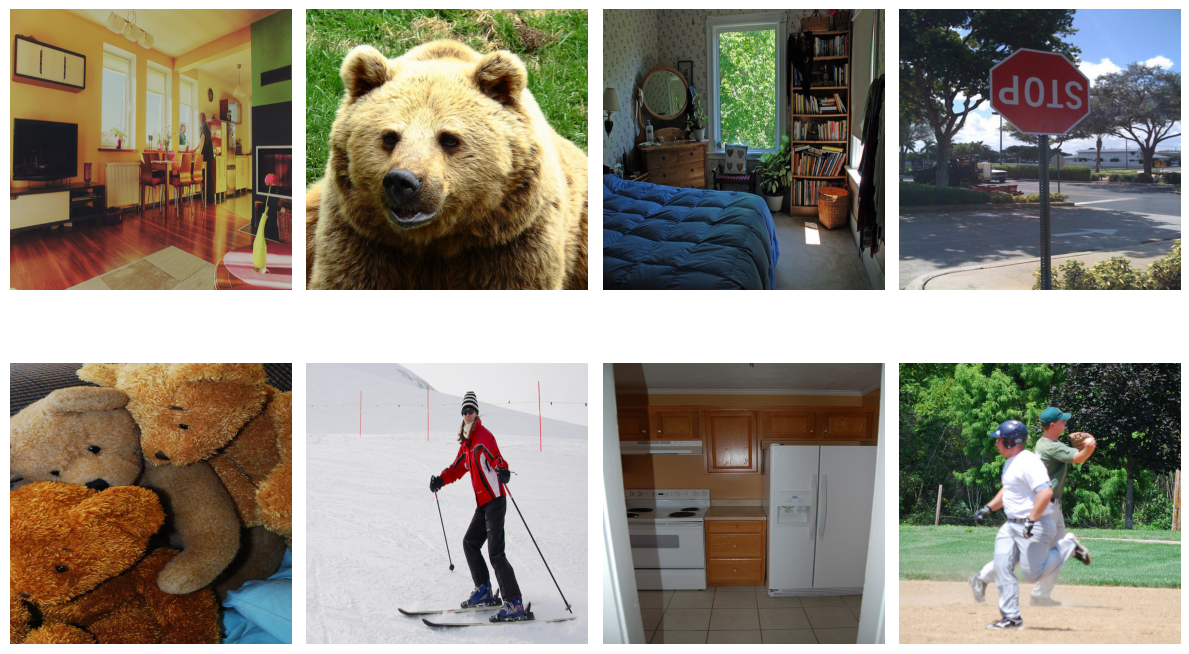

In [15]:
from createDataset import Dataset

image_dir = '../val20171' 
max_images = 16
batch_size = 16

ds = Dataset(root_dir=image_dir, max_images=max_images, target_size=(640, 640))
images, tensors = ds.prepare_images()  # No arguments needed now
ds.show_images(images, n=8)

In [18]:
# Initial Benchmarking on YOLOv8 exported in FP32 format
print("Starting initial benchmarking...")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
IMAGES_PER_BATCH = 16  # Adjust based on your GPU memory
batches = torch.stack(tensors[:IMAGES_PER_BATCH], dim=0).to(device)
batches = batches.contiguous()

start_event = torch.cuda.Event(enable_timing=True)
end_event = torch.cuda.Event(enable_timing=True)

Starting initial benchmarking...


In [21]:
import statistics
def run_inference(model_engine, batch):
    start_event.record()
    with torch.no_grad():
        output = model_engine(batch)
    end_event.record()
    torch.cuda.synchronize()
    elapsed_time = start_event.elapsed_time(end_event)  
    return output, elapsed_time

num_trials = 100
all_timings = []  
results = []

for i in range(num_trials):
    output, elapsed_time = run_inference(model_engine, batches)
    results.append(output)
    all_timings.append(elapsed_time)  # Store the time for this trial
    print(f"Trial {i+1}: Inference time for batch: {elapsed_time:.4f} ms")


if all_timings:  # Check if list is not empty
    avg_batch_results_TensorRT = sum(all_timings) / len(all_timings)
    avg_image_tensorRT = avg_batch_results_TensorRT / IMAGES_PER_BATCH

    avg_batch_s = avg_batch_results_TensorRT / 1000.0
    avg_image_s = avg_image_tensorRT / 1000.0
    
    median_ms = statistics.median(all_timings)
    p95_ms = sorted(all_timings)[int(0.95 * len(all_timings))]
    
    print(f"\n=== Benchmark Results ===")
    print(f"Average inference time per batch: {avg_batch_results_TensorRT:.2f} ms ({avg_batch_s:.6f} s)")
    print(f"Average inference time per image: {avg_image_tensorRT:.2f} ms ({avg_image_s:.6f} s)")
    print(f"Median: {median_ms:.2f} ms, 95th percentile: {p95_ms:.2f} ms")
else:
    print("No timing data collected.")


0: 640x640 3 chairs, 1 potted plant, 1 tv, 1 clock, 3 vases, 18.7ms
1: 640x640 1 bear, 18.7ms
2: 640x640 1 bottle, 1 chair, 2 potted plants, 1 bed, 1 book, 1 vase, 18.7ms
3: 640x640 2 stop signs, 18.7ms
4: 640x640 4 teddy bears, 18.7ms
5: 640x640 1 person, 1 skis, 18.7ms
6: 640x640 1 oven, 1 refrigerator, 18.7ms
7: 640x640 2 persons, 1 sports ball, 18.7ms
8: 640x640 13 persons, 1 tennis racket, 18.7ms
9: 640x640 13 persons, 1 tennis racket, 18.7ms
10: 640x640 4 persons, 1 bird, 1 backpack, 1 handbag, 1 cell phone, 18.7ms
11: 640x640 2 persons, 1 cell phone, 18.7ms
12: 640x640 4 persons, 18.7ms
13: 640x640 1 cup, 1 donut, 18.7ms
14: 640x640 1 person, 1 kite, 1 surfboard, 18.7ms
15: 640x640 1 tv, 1 laptop, 3 mouses, 1 keyboard, 18.7ms
Speed: 0.1ms preprocess, 18.7ms inference, 2.1ms postprocess per image at shape (1, 3, 640, 640)
Trial 1: Inference time for batch: 408.9462 ms

0: 640x640 3 chairs, 1 potted plant, 1 tv, 1 clock, 3 vases, 3.4ms
1: 640x640 1 bear, 3.4ms
2: 640x640 1 bottle